### **Model Evaluation** 🟢

#### **Akaike Information Criterion** 🟢

As explained by Akaike (1998), a parsimonious model uses the smallest number of inputs relative to the sample size, whilst achieving the maximum GoF-value; itself measurable using the well-known Akaike Information Criterion (AIC).

#### **Pseudo R-squared** 🟢

Another useful GoF-measure is the pseudo coefficient of determination for BR-models, denoted as $𝑅^2_F$ ∈ [0, 1], which Ferrari and Cribari-Neto (2004) described as the squared sample correlation between the linear predictors.

For the MLR-models, we use the McFadden pseudo $𝑅^2_\text{McF}$ ∈ [0, 1] measure, which compares the deviance of a fitted model to that of the null model, as detailed by McFadden (1972) and Menard (2000).

#### **Statistical Significance Test** 🟡

Secondly, we test the statistical significance of a particular input, which is based on both the Wald-statistic for BR-models (given their small sample sizes) and the likelihood ratio test for MLR-models (given their large sample sizes), as discussed by Heinze et al. (2018).

#### **Kolmogorov-Smirnov Test** 🟢

It is standard practice in statistical modelling to analyse the residuals $𝑟_𝑖 = 𝑦_𝑖 − \hat 𝑦_𝑖$ between a model’s predictions $\hat 𝑦_𝑖$ and the outcomes $𝑦_𝑖$ for observations 𝑖 = 1, . . . , 𝑛, thereby assessing the model’s goodness-of-fit to its training data. However, these ‘raw’ residuals of BR-models are not typically used given that the outcomes (and the resulting BR-models) are generally heteroscedastic, as discussed by Ferrari and Cribari-Neto (2004) and Cribari-Neto and
Zeileis (2010). Instead, these authors suggested that one should use Pearson residuals (also called standardised ordinary residuals), which are calculated as:

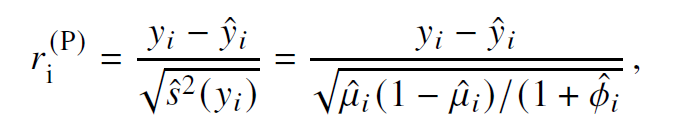

For each of the BR-models, we compare the distribution of Pearson residuals to a standard normal distribution. We then analyse the Pearson residuals of each BR-model in gauging the model fit, and tested the residual distributions for normality using the  Kolmogorov-Smirnov (KS) test at a significance level of 𝛼 = 5%.

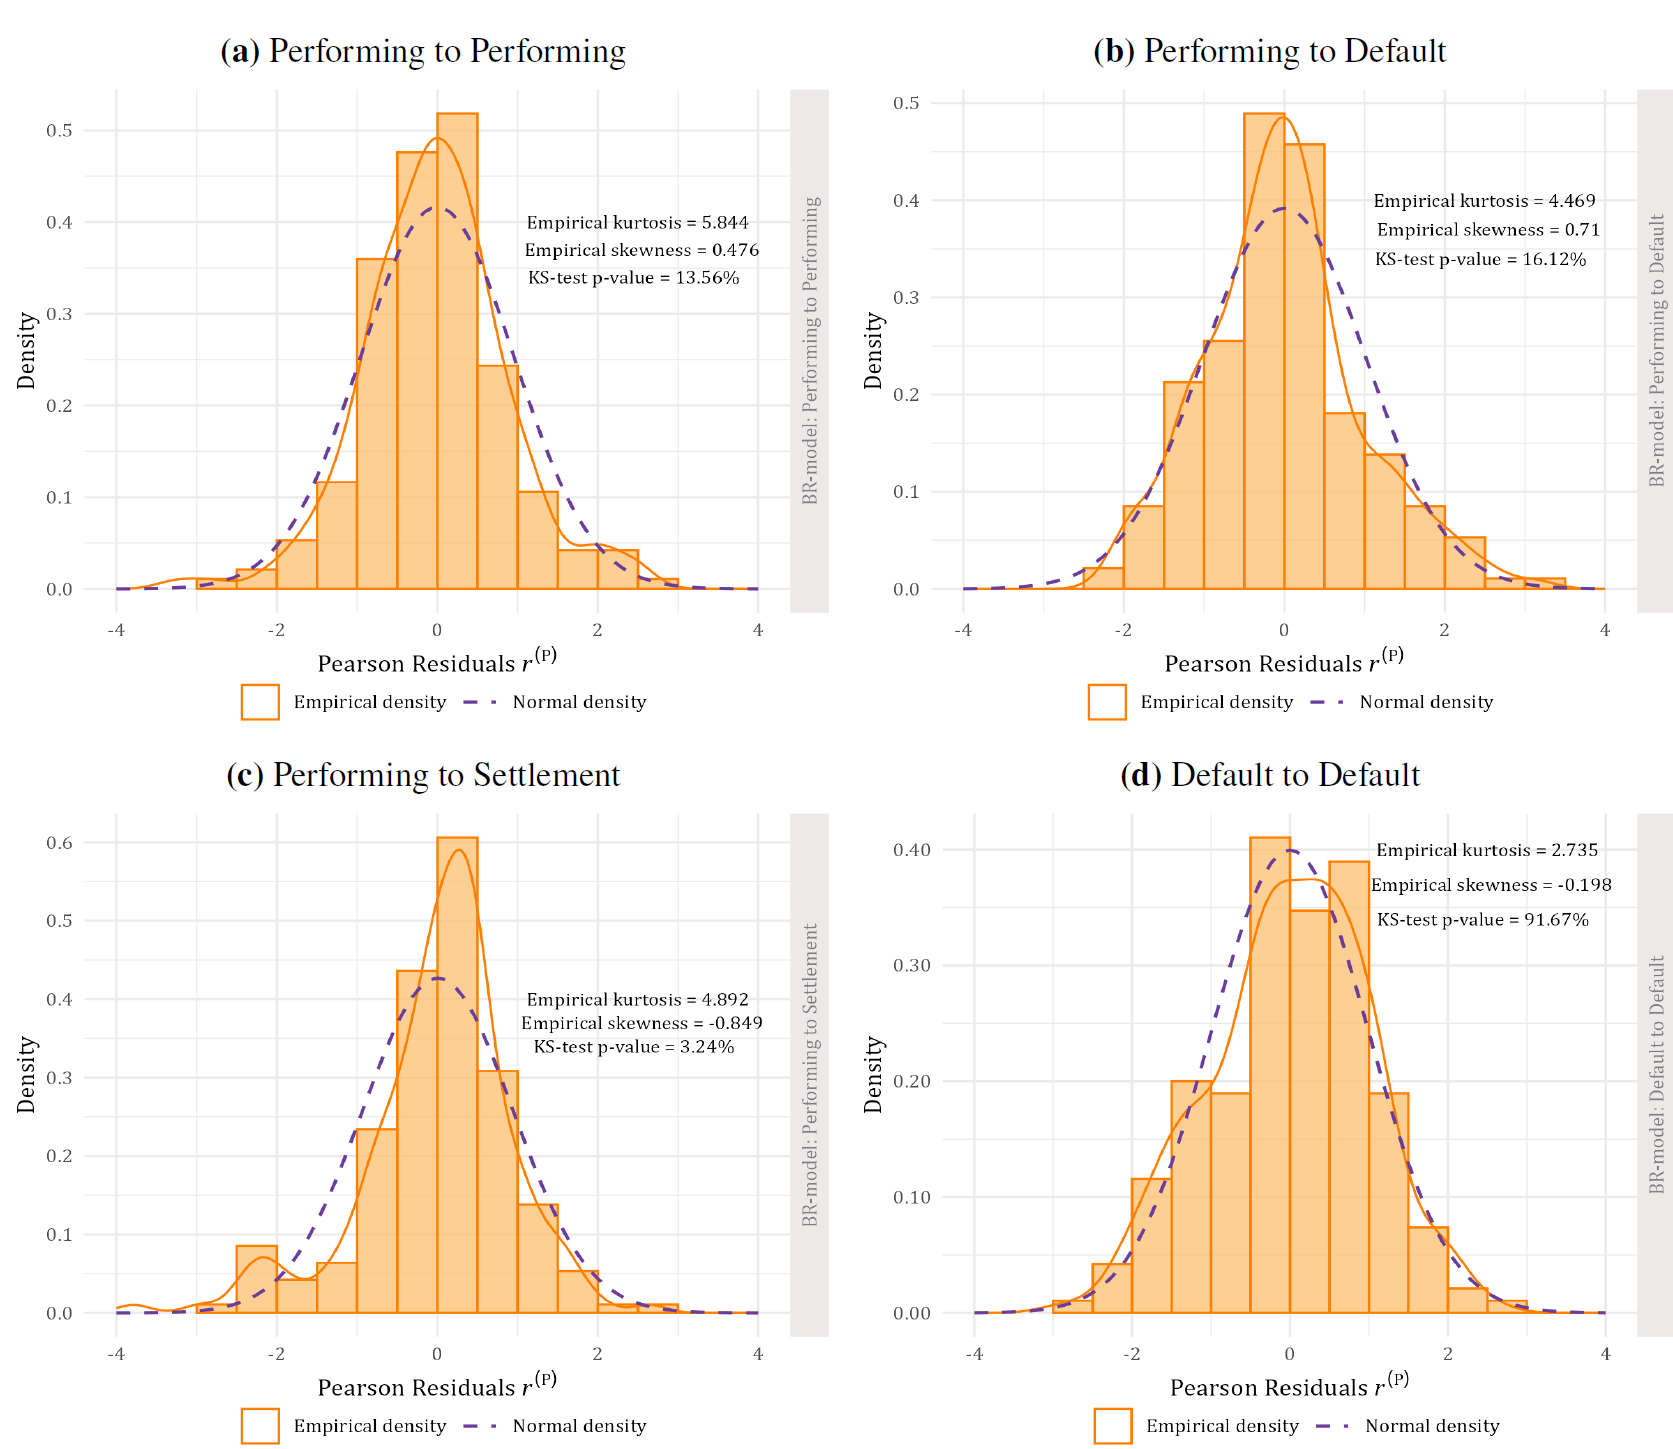

#### **AUC & ROC** 🟢

In summarising an ROC-analysis on each transition type 𝑘 → 𝑙, the AUC is
calculated both in-sample within $D_𝑇$ and out-of-sample within $D_𝑉$. Each AUC-statistic is accompanied by 95% confidence intervals, calculated using the DeLong-method.

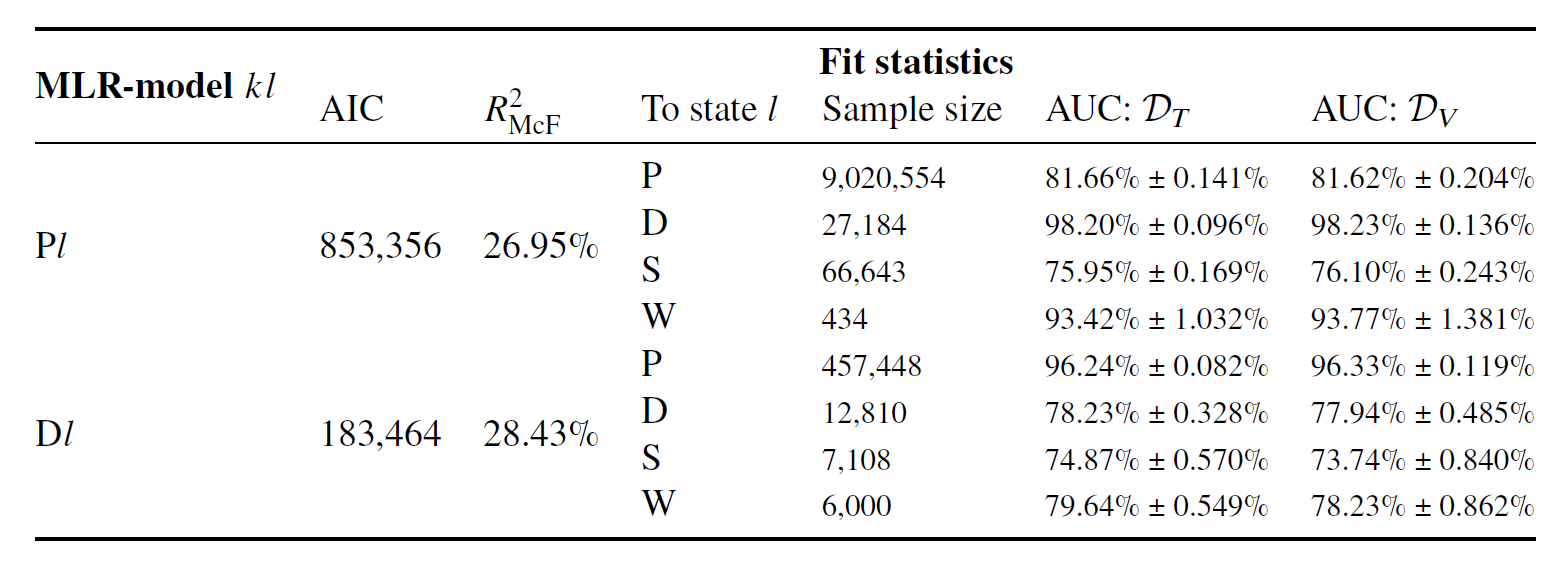

#### **AvE Backtesting (Many Cohorts to One Rate)** 🟢

Our models may be compared by aggregating their predictions to the portfolio-level using the $m$-month state transition rate of type 𝑘 → 𝑙. The BR-models already produce predicted transition rates at the
portfolio-level over calendar time. For comparison purposes, we therefore need only contend with aggregating those predictions from the loan-level MLR-models to the portfolio-level.

Accordingly, the arithmetic average is taken across the loan-level predictions for all loans 𝑖 in each monthly cohort, all of which reconstitutes the validation set. We then express the MLR-variant of the portfolio-level predicted transition rate at any given 𝑡' as:

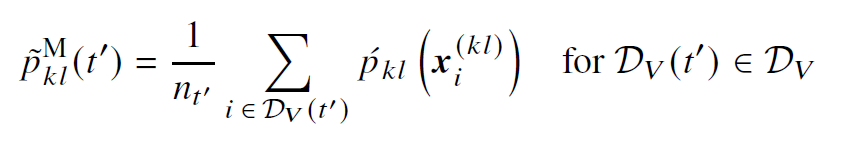

This can also be done on an exposure weighted basis.

These expected estimates can now be compared over 𝑡' to the actual time-dependent transition rate. Note that the corresponding estimate that arises from the Markov chain remains the same across all 𝑡'.

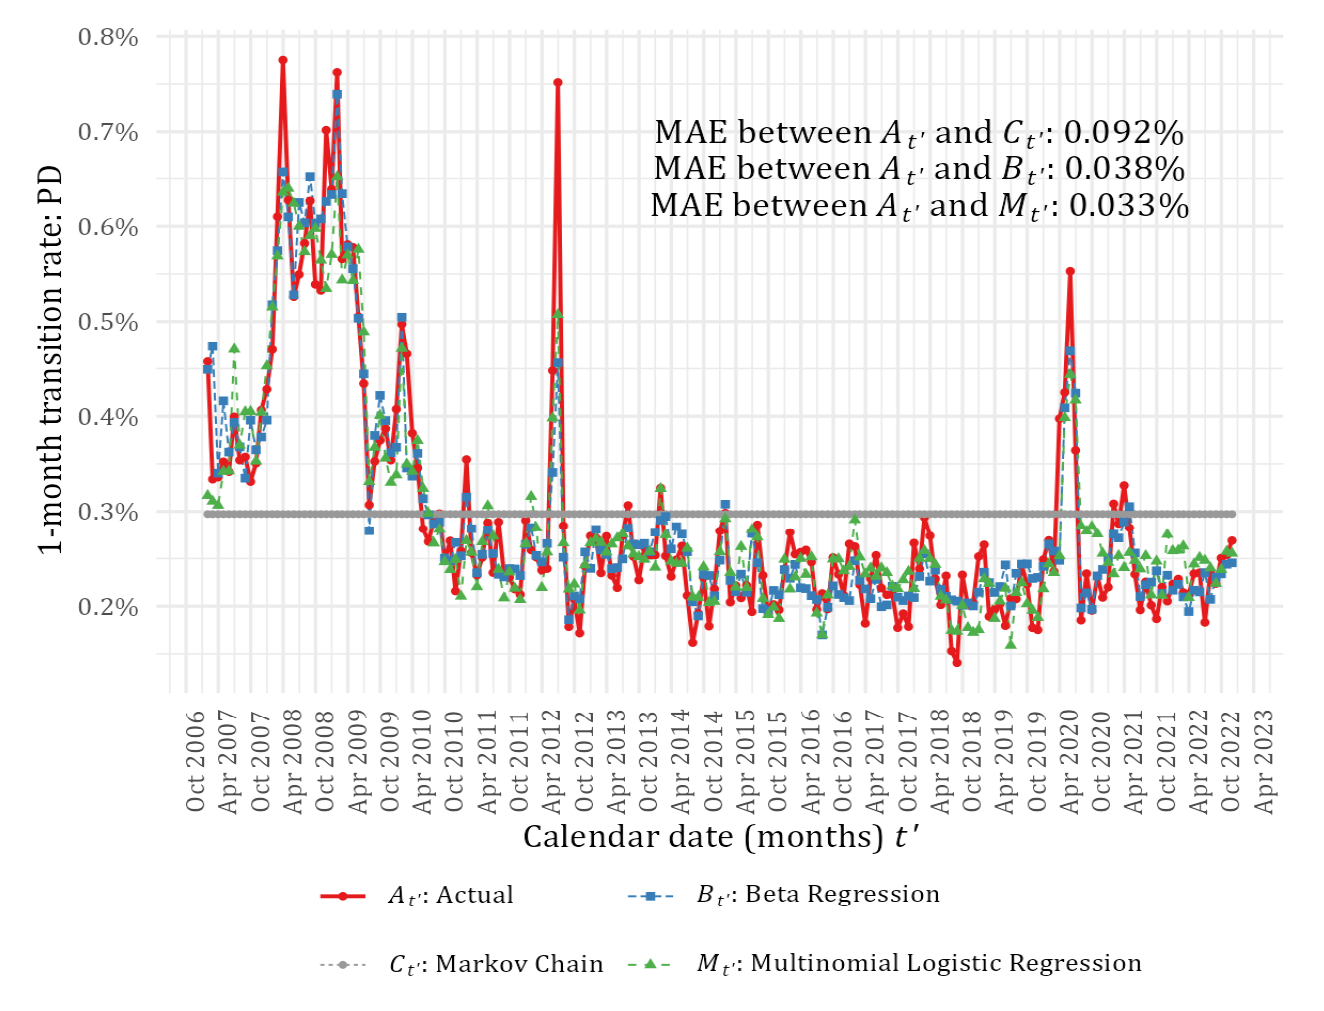

#### **Term Structure Backtesting (1 Cohort to Many Rates)** 🟢

Aside from the m-month state transition rate, we also assess our models by calculating and comparing the implied PD term-structures of all loans within a particular loan cohort e.g. 𝑡' = Jan-2007, which is observed until maturity.

In particular, consider the empirical (actual) transition matrices $\hat 𝑇(𝑡′1), ..., \hat 𝑇(𝑡′_𝑛)$, with elements $\hat 𝑝_{𝑘𝑙}(𝑡') = \large\frac{n_{𝑘𝑙}(𝑡')}{n_{𝑘}(𝑡')}$. These matrices are multiplied recursively as $𝑇^*(𝑡') = \hat 𝑇(𝑡'−1) \hat 𝑇(𝑡')$

i.e., It is the collection of PIT probabilities at each $𝑡'_𝑗$ , having survived up to $𝑡'_{𝑗 − 1}$. In this study, we are however interested only in those cumulative transition rates of type P→D, which signify the PD-term-structure.

Furthermore, we form a time-dependent expected transition matrix $𝑇^{(e)} (𝑡')$ from the portfolio-level estimates of 𝑝_{𝑘𝑙}(𝑡') that result from each modelling technique, having aggregated the loan-level
predictions from the MLR-model using the arithmetic average equation from above.

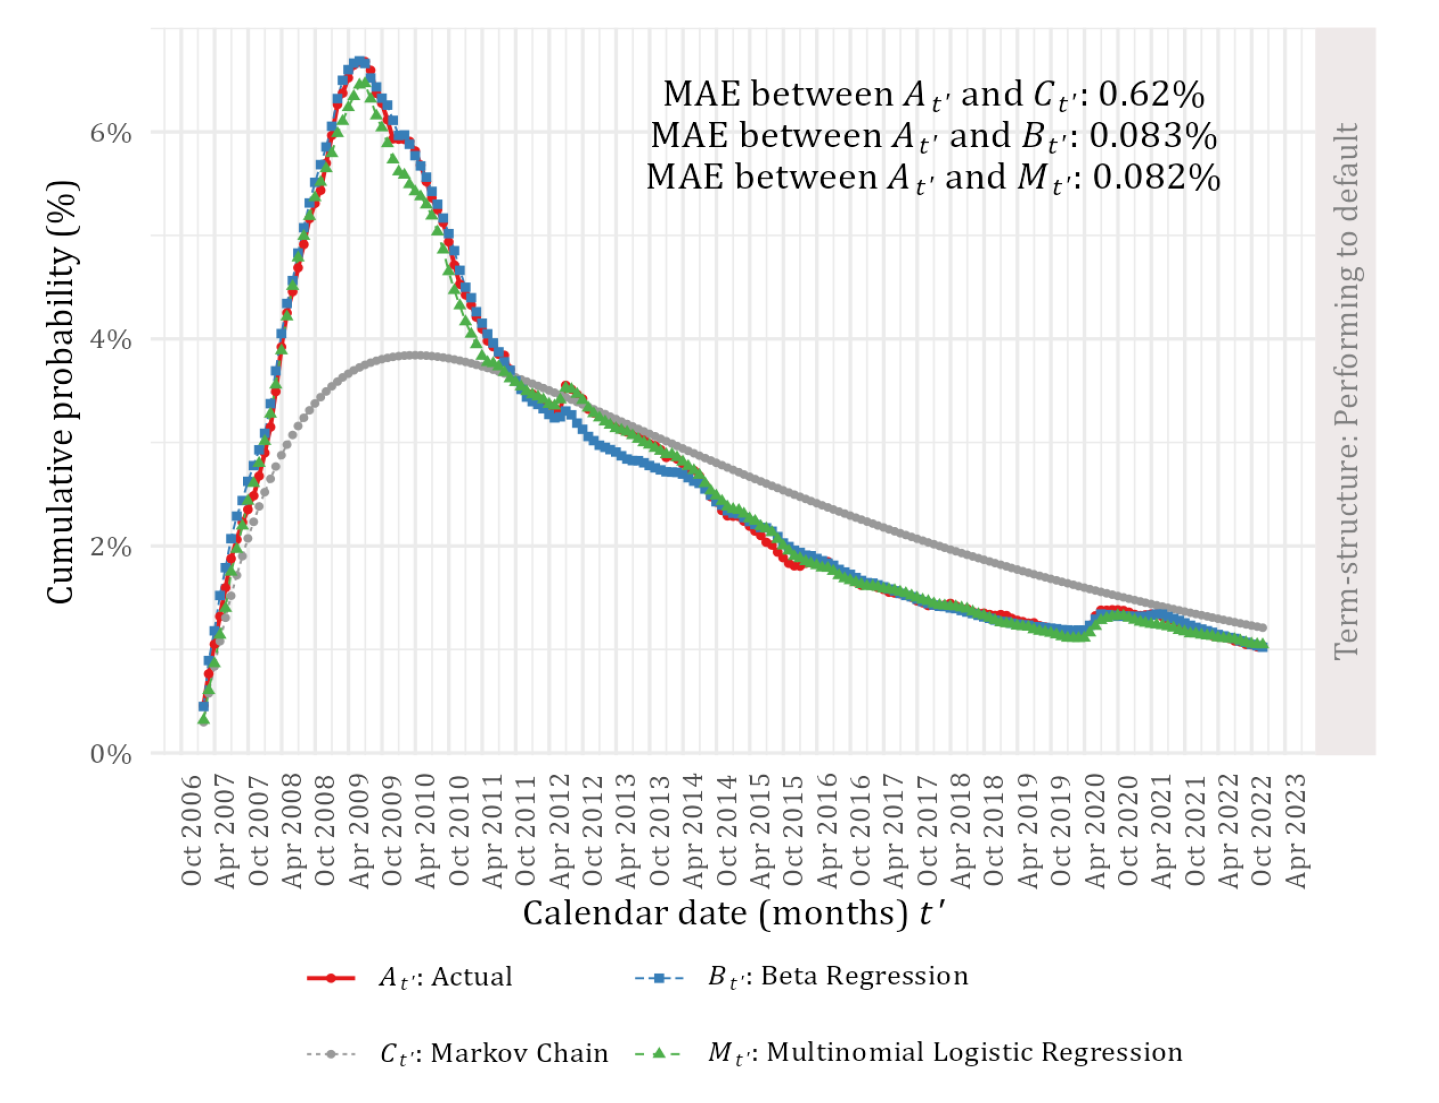

#### **Mean Absolute Error** 🟢

The level of agreement between any combination of actual and expected transition rates can be measured as follows. We compute the MAE between any two rates and compare the subsequent MAE-based values across modelling techniques, which is similar to the use of MAE in testing the sampling representativeness. 


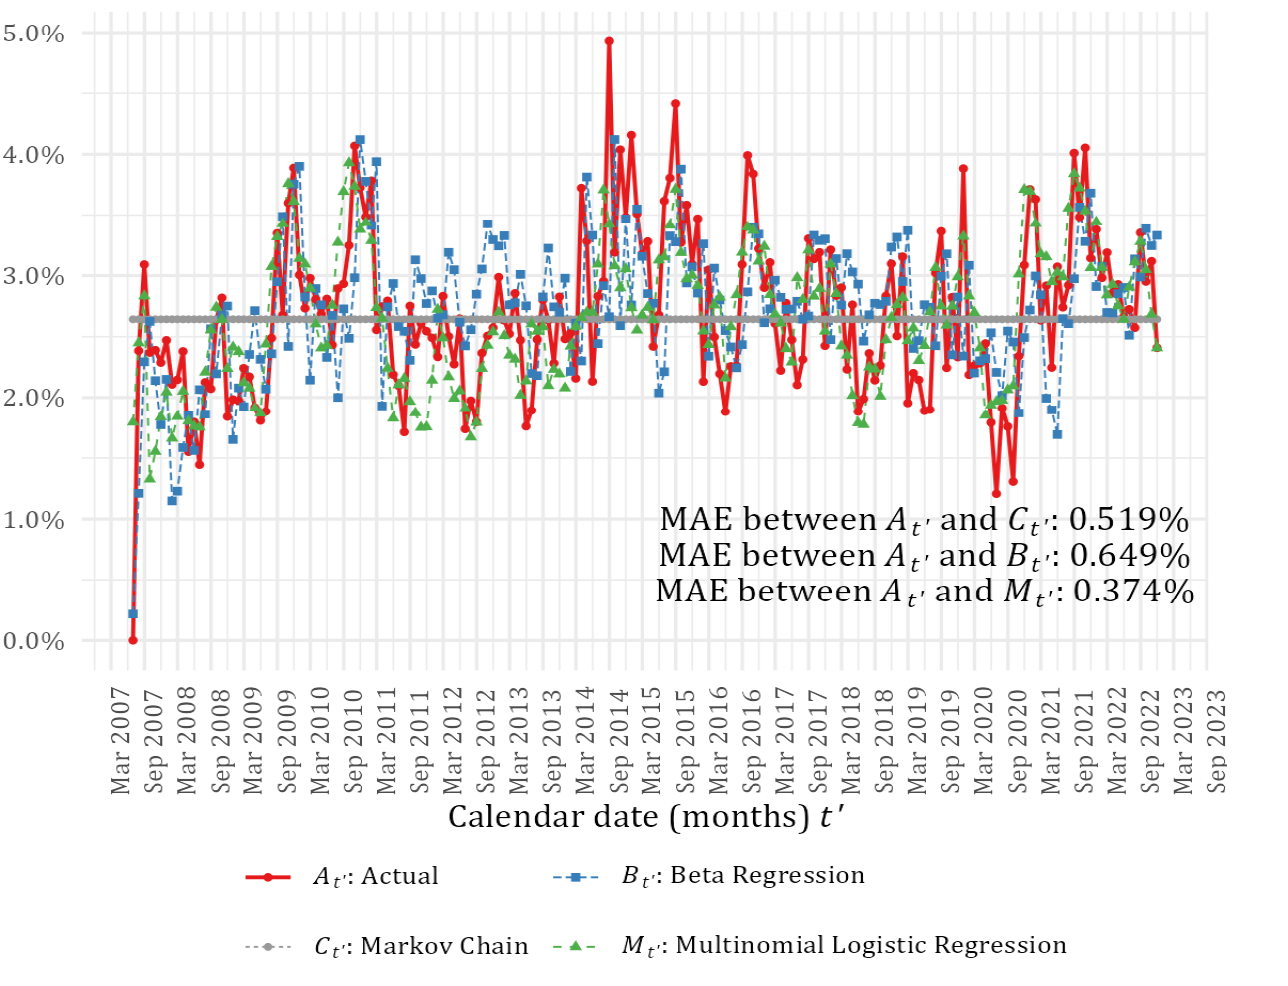

#### **MAE Average Discrepancy Statistic** 🟢

Using the validation sets, this method of comparison relies again on the aforementioned MAE-based statistic, whereby the m-month transition rates – as produced by each modelling technique – are calculated, compared, and summarised
over time into a single portfolio-level statistic.

These AD-statistics confirmed visual analyses. More formally, and for any pair of rates $\{𝑟_1(𝑡'), 𝑟_2(𝑡')\}$ observed over calendar time 𝑡', we define the MAE-based average discrepancy (AD) statistic as:

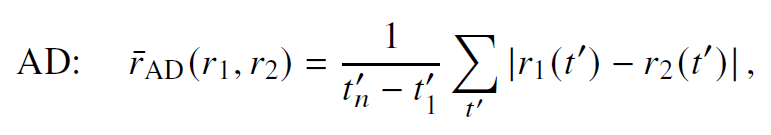

#### **Confidence Interval Backesting**

Having calculated the measurement error, the confidence interval per snapshot i and horizon t, is constructed using a normal test by assuming a 95% confidence level:

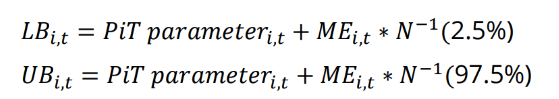

To get the backtest conclusion (pass/fail), it needs to be identified if the observed values fall within the bounds calculated around 
the PIT parameters:

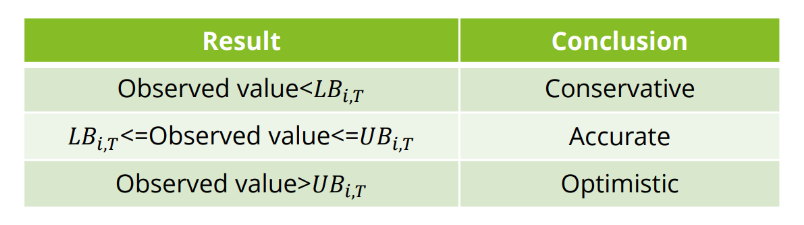

For the share of snapshots that fall outside of the confidence bounds, the materiality of potential model errors is estimated as the impact assessment on 
provisions. The impact on provisions is a sum of the partial impacts per each time horizon. The partial impact per horizon is equal to the average relative 
exceedance of confidence bounds over the I reporting dates in horizon t times the provision amount in horizon t:

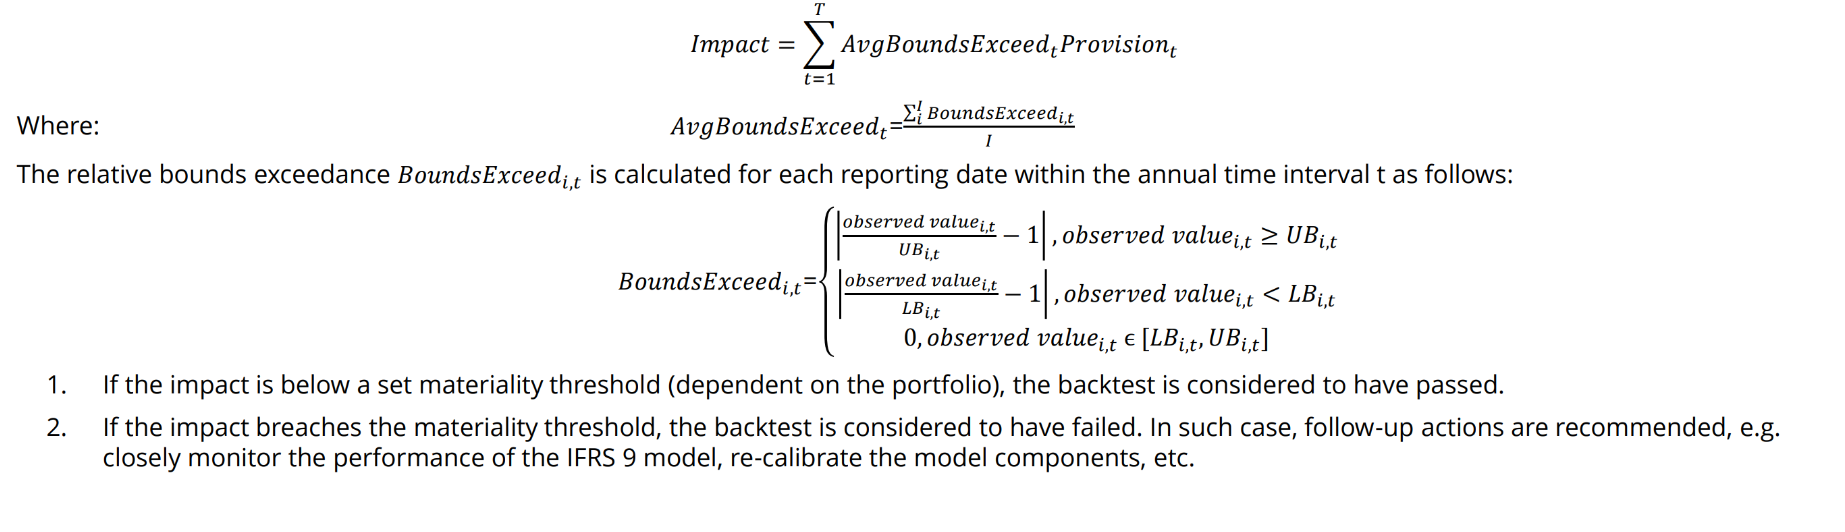

#### **Gini Backtesting** 🟡

Discriminatory power measures the model's ability to rank accounts correctly by default risk. High discriminatory power (e.g., Gini ≈ 0.7 or higher) indicates the model can distinguish between high-risk and low-risk accounts.

**Snapshot-Based Backtesting**

Evaluate Gini/AUC at multiple time points (snapshots). Compare predicted probabilities or scores against actual defaults over the evaluation horizon.

**Stage-Based Segmentation**

Segment accounts into Stage 1 (low risk) and Stage 2 (high risk). Expect Stage 1 + Stage 2 Ginis to be high (e.g., 0.6–0.8) but Stage 2 Ginis to be lower, reflecting lower discriminatory power within already high-risk accounts.
